In [1]:
import numpy as np
import pandas as pd
import pickle
from matplotlib import pyplot as plt
import os

In [2]:

# # Base directory
# base_dir = '/nfs/home/dannis/AC-model/TIM_fix_mean_results/theta_1.41e-06_alpha_27.93'

# # Storage for all trade data
# all_trades = {}
# file_info = []

# # Iterate through subfolders
# for filename in os.listdir(base_dir):
    
#     if filename.endswith('.pkl'):
#         file_path = os.path.join(base_dir, filename)
#         print(f"  Reading file: {filename}")
        
#         try:
#             with open(file_path, 'rb') as f:
#                 data = pickle.load(f)
            
            
#             # Extract key info from filename and subfolder
#             key = f"{filename}"
#             all_trades[key] = data['trades']
#             file_info.append({
#                 'key': key,
#                 'filename': filename,
#                 'trades': data['trades'],
#                 'mip_gap': data.get('mip_gap', None),
#                 'status': data.get('status', 'unknown'),
#             })
                
#         except Exception as e:
#             print(f"    Error reading {filename}: {e}")


In [42]:
data.keys()

dict_keys(['status', 'trades', 'obj_val', 'mip_gap', 'runtime', 'tail_prob', 'inventory', 'errors', 'kappa_samp', 'gamma_samp', 'rho_samp'])

In [2]:

# Base directory
base_dir = '/nfs/home/dannis/AC-model/TIM_fix_mean_results'


# Storage for all trade data
all_trades = {}
file_info = []

# Iterate through subfolders
for subfolder in os.listdir(base_dir):
    subfolder_path = os.path.join(base_dir, subfolder)
    if os.path.isdir(subfolder_path):
        print(f"Processing subfolder: {subfolder}")
        
        # Iterate through files in subfolder
        for filename in os.listdir(subfolder_path):
            if filename.endswith('.pkl'):
                file_path = os.path.join(subfolder_path, filename)
                print(f"  Reading file: {filename}")
                
                try:
                    with open(file_path, 'rb') as f:
                        data = pickle.load(f)
                    
                    
                    # Extract key info from filename and subfolder
                    key = f"{subfolder}_{filename}"
                    all_trades[key] = data['trades']
                    file_info.append({
                        'key': key,
                        'subfolder': subfolder,
                        'filename': filename,
                        'trades': data['trades'],
                        'status': data.get('status', 'unknown'),
                        'mip_gap': data.get('mip_gap', None),
                        'obj_val': data.get('obj_val', None)
                    })
                        
                except Exception as e:
                    print(f"    Error reading {filename}: {e}")


Processing subfolder: fixed_mean_5
Processing subfolder: 4_theta_0.0_alpha_0.0
  Reading file: opt_0.0_21.pkl
  Reading file: opt_0.0_19.pkl
  Reading file: opt_0.0_28.pkl
  Reading file: opt_0.0_25.pkl
  Reading file: opt_0.0_13.pkl
  Reading file: opt_0.0_29.pkl
  Reading file: opt_0.0_14.pkl
  Reading file: opt_0.0_30.pkl
  Reading file: opt_0.0_18.pkl
  Reading file: opt_0.0_22.pkl
  Reading file: opt_0.0_12.pkl
  Reading file: opt_0.0_23.pkl
  Reading file: opt_0.0_20.pkl
  Reading file: opt_0.0_27.pkl
  Reading file: opt_0.0_24.pkl
  Reading file: opt_0.0_16.pkl
  Reading file: opt_0.0_26.pkl
  Reading file: opt_0.0_31.pkl
  Reading file: opt_0.0_15.pkl
  Reading file: opt_0.0_17.pkl
  Reading file: opt_0.0_11.pkl
Processing subfolder: fixed_mean_2
Processing subfolder: 1_theta_7.091207e-07_alpha_5.213667
  Reading file: opt_7.091207e-07_13.pkl
  Reading file: opt_7.091207e-07_14.pkl
  Reading file: opt_7.091207e-07_11.pkl
  Reading file: opt_7.091207e-07_12.pkl
  Reading file: o

In [3]:

data_rows = []

for i, info in enumerate(file_info):
    ind = int(info['subfolder'].split('_')[0])
    if ind not in [0, 3, 4]:
        continue
    theta_var = float(info['subfolder'].split('_')[2])
    seed = info['filename'].split('_')[-1].split('.')[0]
    trades = np.array(info['trades'])
        
    # Create a row with ntrades, seed, and each trade element as separate columns
    row = {
        'theta_var': theta_var,
        'seed': seed,
        'mip_gap': info.get('mip_gap', None),
        'ind': ind,
        'obj_val': info.get('obj_val', None)
    }
    
    # Add each trade element as a separate column (trade_0, trade_1, ..., trade_10)
    for j, trade in enumerate(trades):
        row[f'trade_{j}'] = trade
    
    data_rows.append(row)

# Create DataFrame
df = pd.DataFrame(data_rows)
    


In [4]:
df.groupby('theta_var').agg({
    'mip_gap': ['mean', 'std'],
    'obj_val': ['mean', 'std']
})


mip_gap               obj_val           
                  mean       std        mean        std
theta_var                                              
0.000000e+00  0.001507  0.000433  739.568993   9.609709
5.268546e-07  0.008334  0.006714  743.292455  11.441101
1.349766e-06  0.016076  0.006746  749.461881  11.667803

In [5]:
df.theta_var.value_counts()

theta_var
0.000000e+00    21
1.349766e-06    21
5.268546e-07    21
Name: count, dtype: int64

In [6]:
df_inventory = 1000 - df.filter(like='trade_').cumsum(axis=1)
df_inventory.columns = [(i + 1) for i in range(df_inventory.shape[1])]
df_inventory[0] = 1000


In [7]:
plt.rcParams['figure.dpi'] = 300

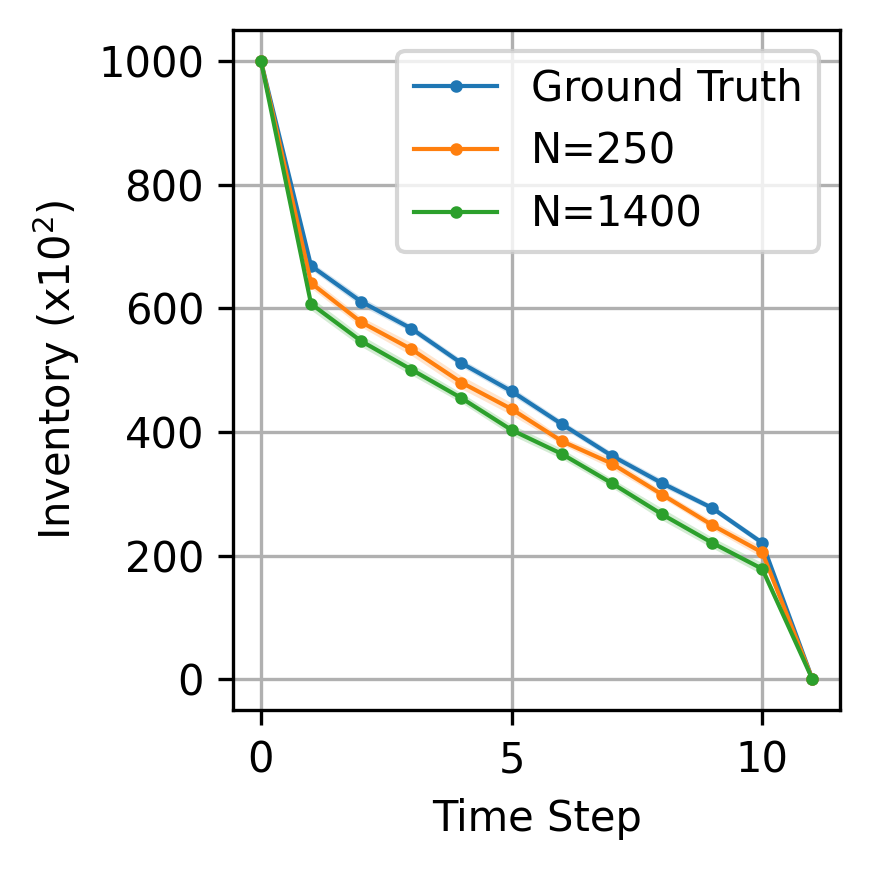

In [17]:


groups = df_inventory.groupby(df['theta_var'])

plt.figure(figsize=(3, 3))

labels=['Ground Truth', 'N=250', 'N=1400']
for i, (theta_var, group) in enumerate(groups):
    
    
    # Calculate mean and standard error for each trade column
    means = []
    std_errors = []
    
    for col in sorted(df_inventory.columns):
        mean_val = group[col].mean()
        std_val = group[col].std()
        n_samples = len(group)
        std_error = std_val / np.sqrt(n_samples)
        
        means.append(mean_val)
        std_errors.append(std_error)
    
    means = np.array(means)
    std_errors = np.array(std_errors)
    x = np.arange(len(means))  # Trade steps 0 to 10

    # Plot mean trajectory
    plt.plot(x, means, marker='o', markersize=2, linewidth=1, label=labels[i])
    
    # Add standard error bands
    plt.fill_between(x, means - std_errors, means + std_errors, alpha=0.2)

plt.xlabel('Time Step')
plt.ylabel('Inventory (x$10^2$)')
# plt.title('Mean Trade Trajectory with Standard Error by theta_var')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('tim_trade.pdf')
plt.show()